# CSI 1000 / IM American Carry-Put Demo

**Valuation date and calibration window:** configured in the first code cell below. The sample size includes the valuation date.  
**Scope:** the carry-put optional component only; the linear IM futures leg is deliberately excluded.

The notebook recalibrates the independent two-factor OU carry model with an $\eta_{fast}$ cap of 6, estimates CSI 1000 historical volatility over the same dates, derives the locked carry from the selected observed futures quote, performs deterministic daily backward induction, and profiles fixed $\eta_{fast}$ values with conditional re-optimization.

## Model and conventions

The carry state is

$$c_t=\theta+x_{s,t}+x_{f,t}, \qquad dx_{j,t}=-\kappa_jx_{j,t}dt+\eta_jdW_t^j,$$

with independent slow and fast shocks and $0<\kappa_s<\kappa_f$. Carry maturity and observation gaps use trading sessions divided by 244. Futures **close** and CSI 1000 spot close are used, with continuously compounded $r=0.014$.

The historical calibration is provisionally interpreted under the pricing measure. This is a prototype assumption, not a production risk-neutral calibration.

In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import Image, Markdown, display

DEMO_ROOT = Path.cwd().resolve()
if DEMO_ROOT.name.lower() != 'demo':
    DEMO_ROOT = DEMO_ROOT / 'Demo'
sys.path.insert(0, str(DEMO_ROOT))

# Reload Demo-local code so rerunning this cell picks up file changes made
# after the current Jupyter kernel was started.
for module_name in [
    'demo_workflow', 'profile_analysis', 'option_pricing',
    'calibration', 'demo_quality', 'calendar_utils',
]:
    sys.modules.pop(module_name, None)

from demo_workflow import run_demo  # noqa: E402

# User inputs: SAMPLE_SIZE counts usable trading dates including VALUATION_DATE.
VALUATION_DATE = '2026-08-10'
SAMPLE_SIZE = 488
FUTURES_CONTRACT = 'IM2612'

# This performs the 12-start calibration, fixed-eta profile, option pricing, and export.
demo = run_demo(
    valuation_date=VALUATION_DATE,
    sample_size=SAMPLE_SIZE,
    futures_contract=FUTURES_CONTRACT,
)
print('Demo completed; outputs:', DEMO_ROOT / 'outputs')

Demo completed; outputs: D:\Jupyter_files\Carry_curve_calibration\Demo\outputs


## 1. Configured calibration sample

In [2]:
sample_keys = [
    'sample_start', 'sample_end', 'curve_dates', 'accepted_observations',
    'excluded_observations_within_window', 'distinct_contracts',
    'return_observations', 'historical_volatility'
]
pd.DataFrame({
    'quantity': sample_keys,
    'value': [demo.calibration.metrics[key] for key in sample_keys],
})

,quantity,value
0,sample_start,2024-08-05
1,sample_end,2026-08-10
2,curve_dates,488
3,accepted_observations,1807
4,excluded_observations_within_window,145
5,distinct_contracts,28
6,return_observations,487
7,historical_volatility,0.277109


The window is selected by **distinct accepted curve date**, not by individual contract row. The 244 closing levels provide 243 close-to-close log returns for historical volatility.

## 2. Two-factor OU maximum-likelihood calibration

In [3]:
parameter_columns = [
    'parameter', 'estimate', 'standard_error',
    'slow_half_life_sessions', 'fast_half_life_sessions'
]
display(demo.calibration.parameter_table[parameter_columns])
pd.DataFrame({
    'diagnostic': ['log likelihood', 'AIC', 'BIC', 'carry RMSE (bp)',
                   'futures RMSE (points)', 'optimizer converged', 'stable Hessian',
                   'eta-fast upper bound', 'eta-fast at bound', 'kappa gap at bound'],
    'value': [demo.calibration.metrics[key] for key in [
        'log_likelihood', 'aic', 'bic', 'carry_rmse_bps',
        'futures_rmse_points', 'optimizer_converged', 'hessian_stable',
        'eta_fast_upper_bound', 'eta_fast_at_upper_bound',
        'kappa_fast_minus_slow_at_upper_bound'
    ]],
})

,parameter,estimate,standard_error,slow_half_life_sessions,fast_half_life_sessions
0,kappa_slow,2.576488,0.139595,65.642822,2.702739
1,kappa_fast,62.576488,4.404933,65.642822,2.702739
2,theta,0.108622,0.001285,65.642822,2.702739
3,eta_slow,0.114955,0.007558,65.642822,2.702739
4,eta_fast,3.885172,0.284776,65.642822,2.702739
5,sigma_epsilon,0.005928,0.000127,65.642822,2.702739


,diagnostic,value
0,log likelihood,5348.42993
1,AIC,-10684.859859
2,BIC,-10651.86332
3,carry RMSE (bp),46.780876
4,futures RMSE (points),10.053984
5,optimizer converged,True
6,stable Hessian,True
7,eta-fast upper bound,6.0
8,eta-fast at bound,False
9,kappa gap at bound,True


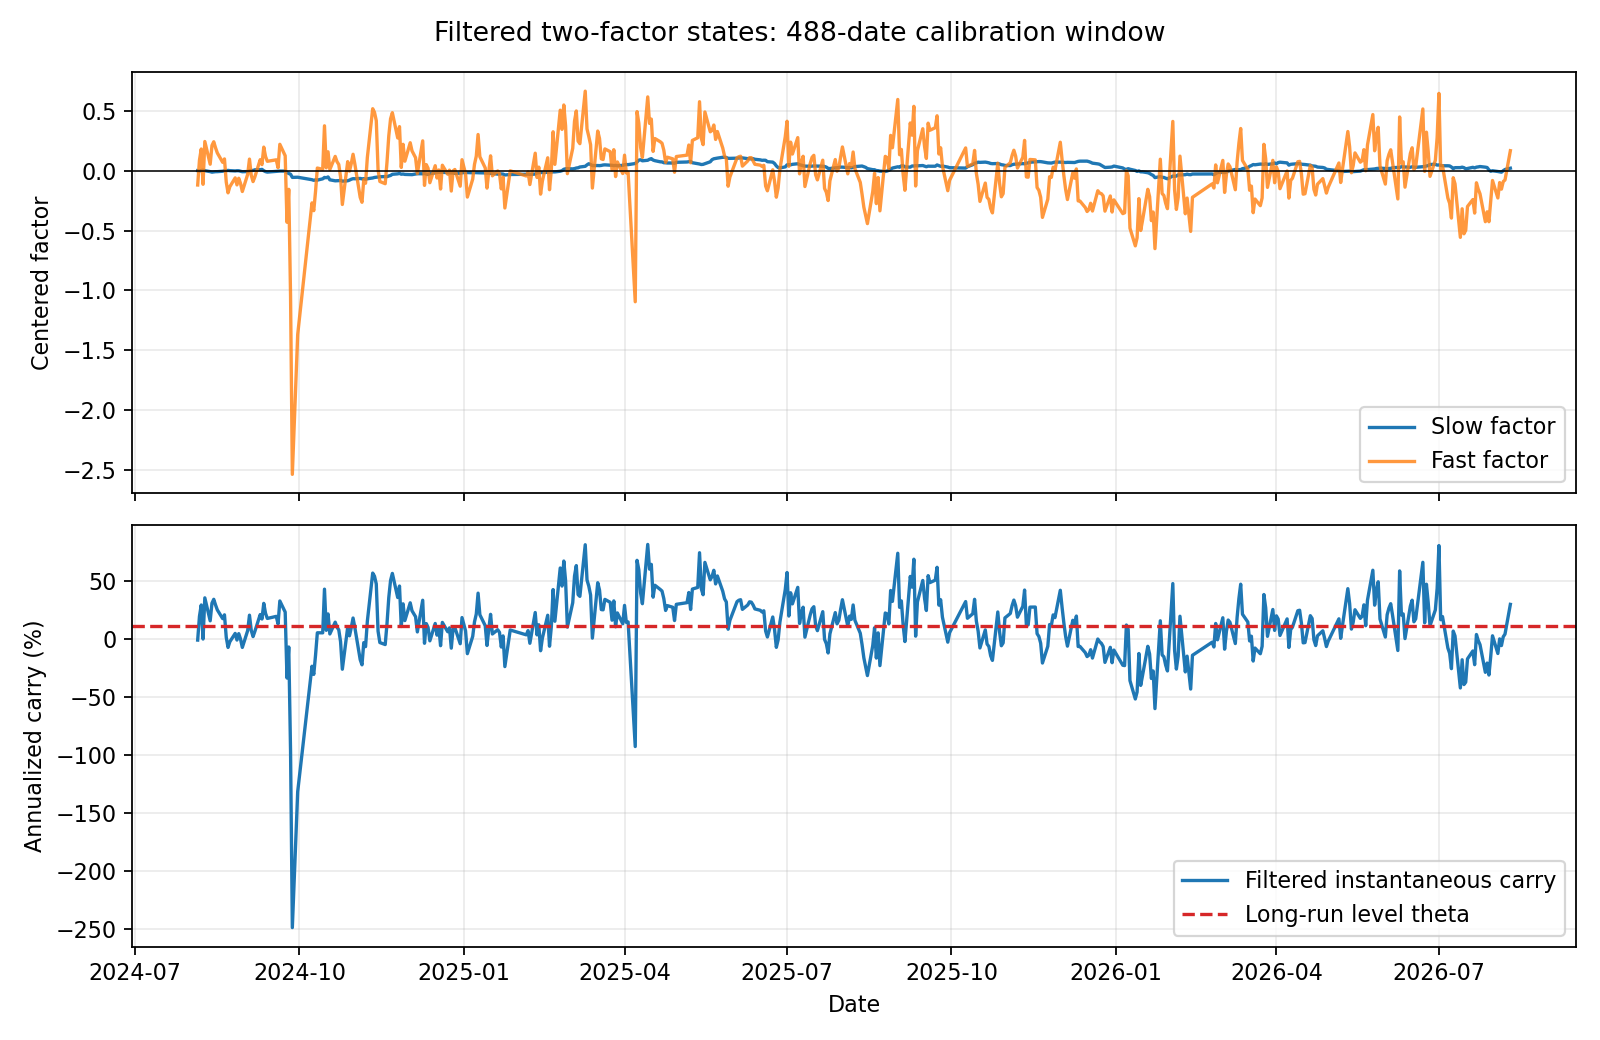

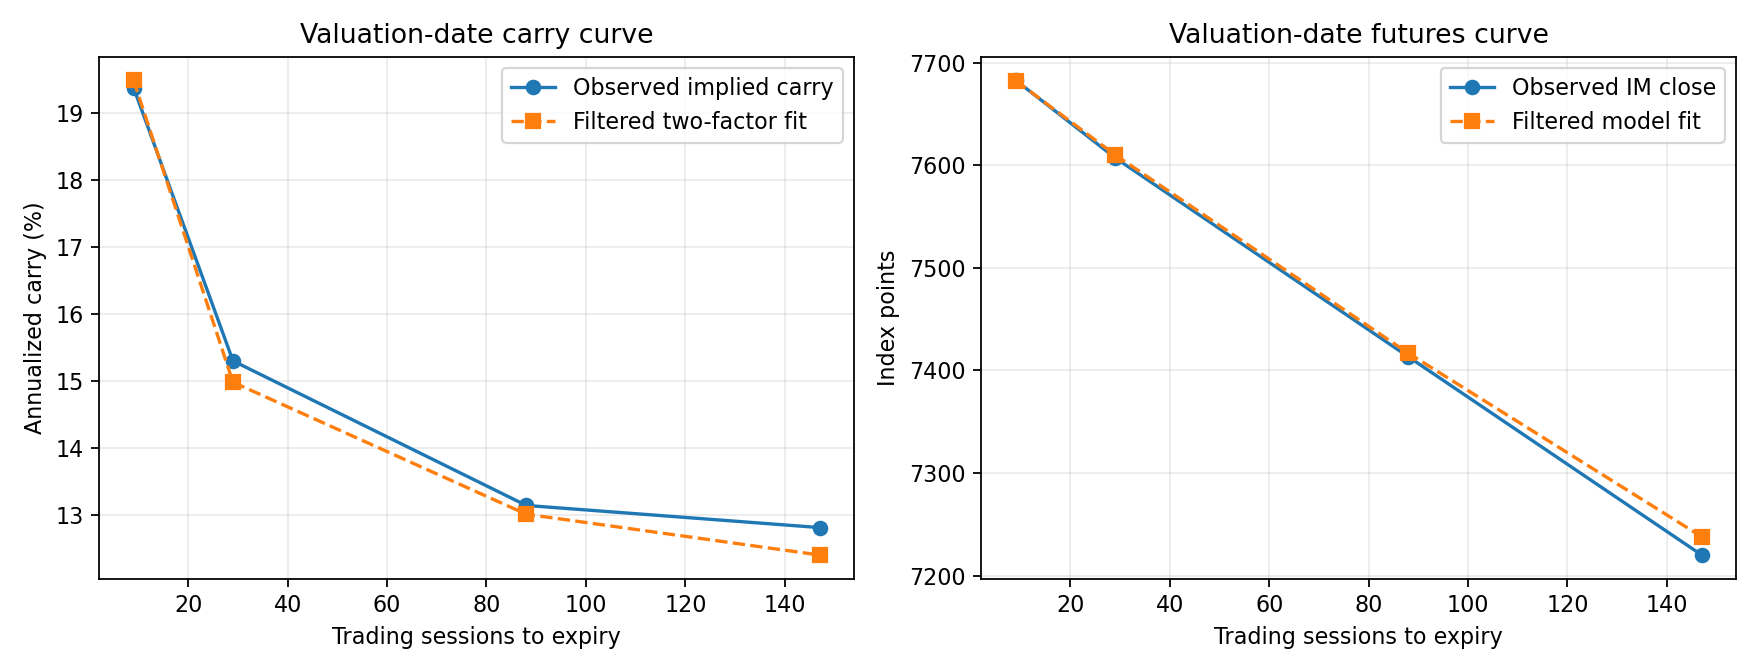

In [4]:
display(Image(filename=str(DEMO_ROOT / 'outputs' / 'charts' / 'filtered_states.png')))
display(Image(filename=str(DEMO_ROOT / 'outputs' / 'charts' / 'latest_curve.png')))

The revised $\eta_{fast}$ cap is 6. An interior estimate resolves the original volatility-bound problem. The demo separately checks the $\kappa_{fast}-\kappa_{slow}$ bound because relaxing one constraint can expose pressure on another.

## 3. Selected-contract locked carry and historical spot volatility

The contractual carry strike is derived from the observed inception quote:

$$q_{0,T}=r-\frac{\log(F_{0,T}/S_0)}{T}, \qquad T=\frac{N_{sessions}}{244}.$$

In [5]:
contract = demo.summary['contract']
display(pd.DataFrame({
    'input': list(contract),
    'value': list(contract.values()),
}))
# display(pd.DataFrame([demo.summary['calendar']['im2703_diagnostic']]).T.rename(columns={0: 'IM2703 calendar status'}))

,input,value
0,valuation_date,2026-08-10
1,contract,IM2612
2,expiry,2026-12-18
3,sessions_to_expiry,88
4,initial_spot,7733.9
5,initial_futures,7413.2
6,risk_free_rate,0.014
7,historical_spot_volatility,0.277109
8,locked_carry,0.131428


## 4. Option-only payoff and pricing

At an exercise date $t$, the complete product can be decomposed as

$$\max\{S_te^{(r-q_{0,T})(T-t)},F_{t,T}\}-F_{0,T} = (F_{t,T}-F_{0,T}) + \left[S_te^{(r-q_{0,T})(T-t)}-F_{t,T}\right]^+.$$

This demo deliberately omits the first, linear futures term. It prices only

$$G_t=S_t\left[e^{(r-q_{0,T})(T-t)}-\frac{F_{t,T}}{S_t}\right]^+.$$

Exercise is checked on every remaining trading session. Exact Gaussian integrated-carry moments and Gauss-Hermite quadrature are used for continuation values.

In [6]:
result = demo.summary['option_result']
result_keys = [
    'price', 'normalized_price', 'locked_carry', 'model_initial_carry',
    'model_initial_futures', 'observed_initial_futures',
    'initial_futures_model_error', 'exercise_steps',
    'spot_volatility_input', 'spot_volatility_affects_price'
]
display(pd.DataFrame({'quantity': result_keys, 'value': [result[k] for k in result_keys]}))
display(Markdown(f"### Option-only value: **{result['price']:.6f} index points** "
                 f"({100 * result['normalized_price']:.6f}% of spot)"))

,quantity,value
0,price,63.857482
1,normalized_price,0.008257
2,locked_carry,0.131428
3,model_initial_carry,0.12817
4,model_initial_futures,7421.916408
5,observed_initial_futures,7413.2
6,initial_futures_model_error,8.716408
7,exercise_steps,88
8,spot_volatility_input,0.277109
9,spot_volatility_affects_price,False


### Option-only value: **63.857482 index points** (0.825683% of spot)

The observed quote determines the locked carry. The exact OU model generally produces a slightly different inception futures value; that model-minus-market difference is shown as a fit diagnostic and is **not** converted into inception exercise value.

## 5. Fixed-$\eta_{fast}$ likelihood and option-price profile

At every profile point, the other five parameters are re-optimized, the valuation-date factors are filtered again, and the carry put is repriced. The unrestricted cap-6 estimate is inserted into the grid as an internal consistency check.

,eta_fast_fixed,kappa_fast,kappa_fast_minus_slow,log_likelihood_below_profile_max,likelihood_ratio_vs_profile_max,relative_likelihood,option_price,option_price_difference_from_cap6_fit
0,2.000000,39.778680,37.477662,-90.881799,181.763598,3.392627e-40,55.261564,-8.595918e+00
1,3.000000,51.920630,49.447115,-12.191783,24.383567,5.071959e-06,61.337269,-2.520213e+00
2,3.250000,55.112372,52.604903,-6.235651,12.471303,1.958353e-03,62.036126,-1.821355e+00
3,3.500000,58.421911,55.883091,-2.594076,5.188152,7.471488e-02,62.444514,-1.412968e+00
4,3.750000,61.855660,59.287952,-0.504058,1.008117,6.040741e-01,62.601134,-1.256348e+00
5,3.885172,62.576488,60.000000,0.000000,0.000000,1.000000e+00,63.857482,2.133046e-07
6,4.000000,62.580671,60.000000,-0.373242,0.746483,6.884989e-01,65.579987,1.722505e+00
7,5.000000,62.610026,60.000000,-24.791125,49.582251,1.711398e-11,80.968531,1.711105e+01
8,6.000000,62.629282,60.000000,-66.826414,133.652828,9.498547e-30,96.678873,3.282139e+01
9,8.000000,62.651028,60.000000,-159.774423,319.548845,4.081783e-70,128.170865,6.431338e+01


,value
eta_grid,"[2.0, 3.0, 3.25, 3.5, 3.75, 3.8851718110983695..."
best_grid_eta_fast,3.885172
best_grid_log_likelihood,5348.42993
log_likelihood_gain_over_cap6_fit,0.0
cap6_option_price,63.857482
eta3_log_likelihood,5336.238146
log_likelihood_gain_over_eta3,12.191783
likelihood_ratio_vs_eta3,24.383567
eta3_option_price,61.337269
cap6_price_difference_from_eta3,2.520213


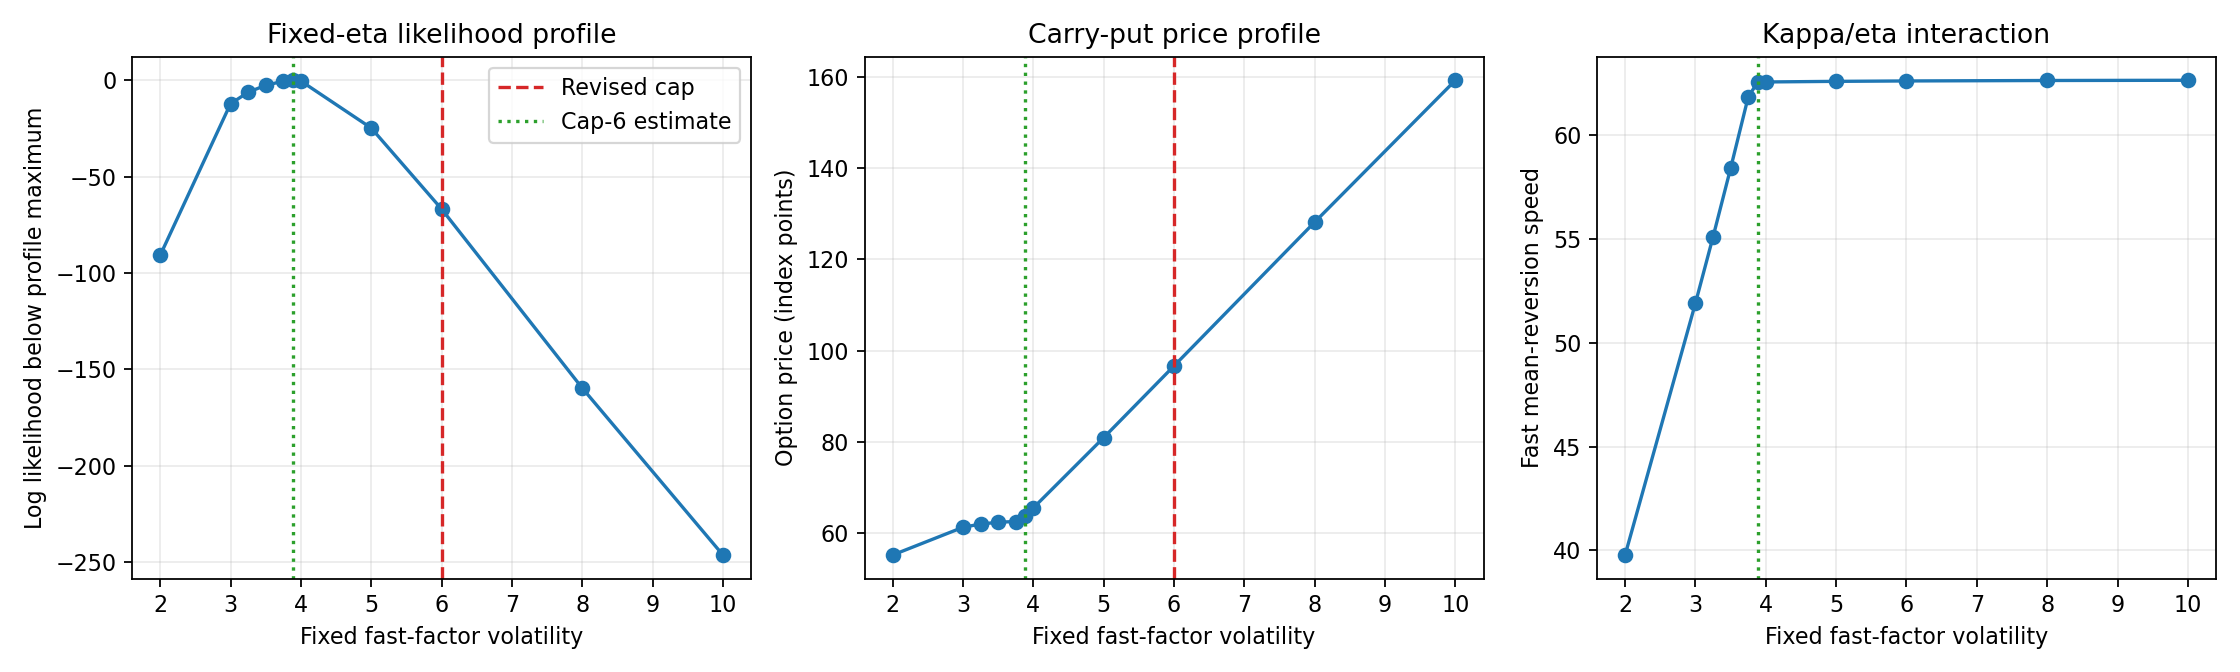

In [7]:
profile_columns = [
    'eta_fast_fixed', 'kappa_fast', 'kappa_fast_minus_slow',
    'log_likelihood_below_profile_max', 'likelihood_ratio_vs_profile_max',
    'relative_likelihood', 'option_price',
    'option_price_difference_from_cap6_fit'
]
display(demo.eta_fast_profile.results[profile_columns])
display(pd.DataFrame([demo.summary['fixed_eta_fast_profile']]).T.rename(columns={0: 'value'}))
display(Image(filename=str(DEMO_ROOT / 'outputs' / 'charts' / 'eta_fast_profile.png')))

## 6. Numerical convergence and exercise diagnostics

,configuration,slow_grid_points,fast_grid_points,stationary_stddev_width,quadrature_order,minimum_half_width,exercise_tolerance,price,normalized_price,difference_from_fine
0,coarse,201,281,6.0,43,0.01,1.000000e-12,63.961790,0.008270,0.148395
1,base,301,401,6.0,43,0.01,1.000000e-12,63.857528,0.008257,0.044133
2,fine,401,501,6.0,43,0.01,1.000000e-12,63.813395,0.008251,0.000000


,quadrature_order,price,normalized_price,difference_from_base_order
0,39,63.856028,0.008257,-0.001500
1,41,63.857294,0.008257,-0.000234
2,43,63.857528,0.008257,0.000000
3,45,63.857704,0.008257,0.000176
4,47,63.857940,0.008257,0.000412


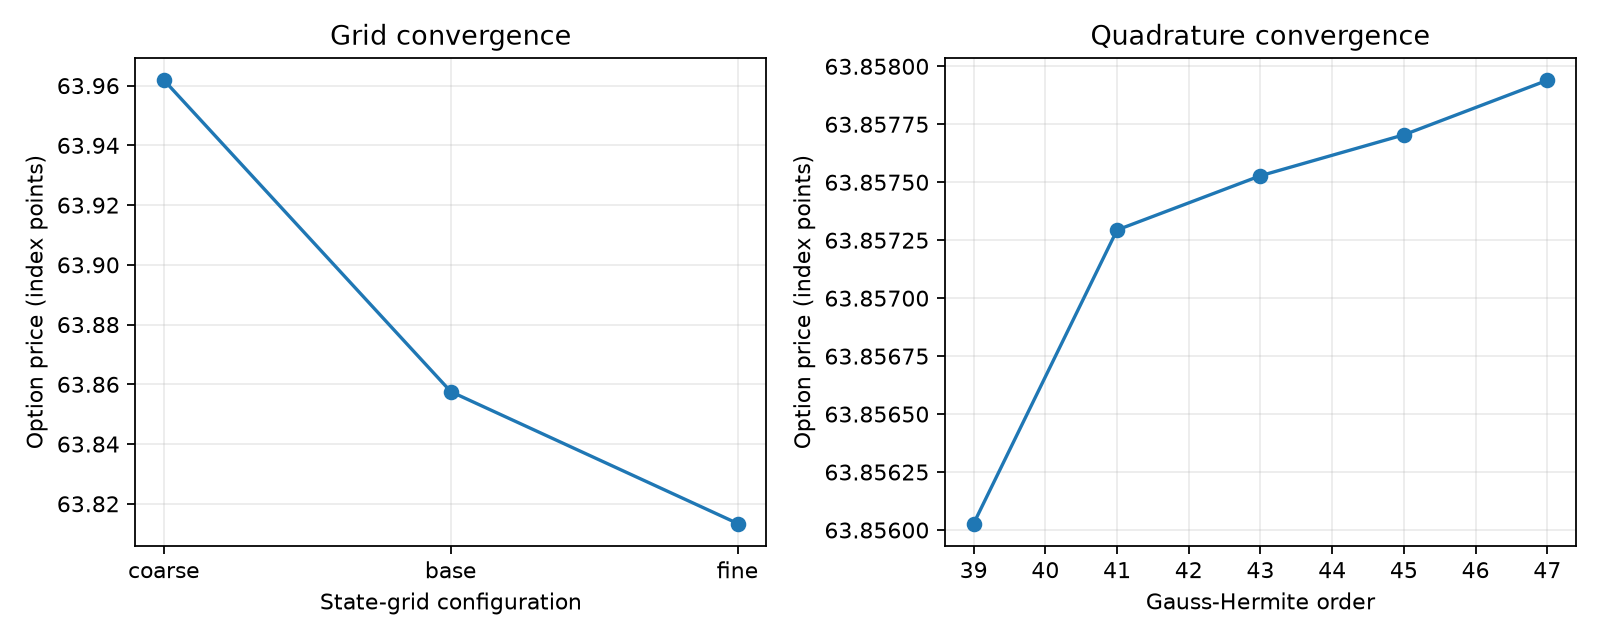

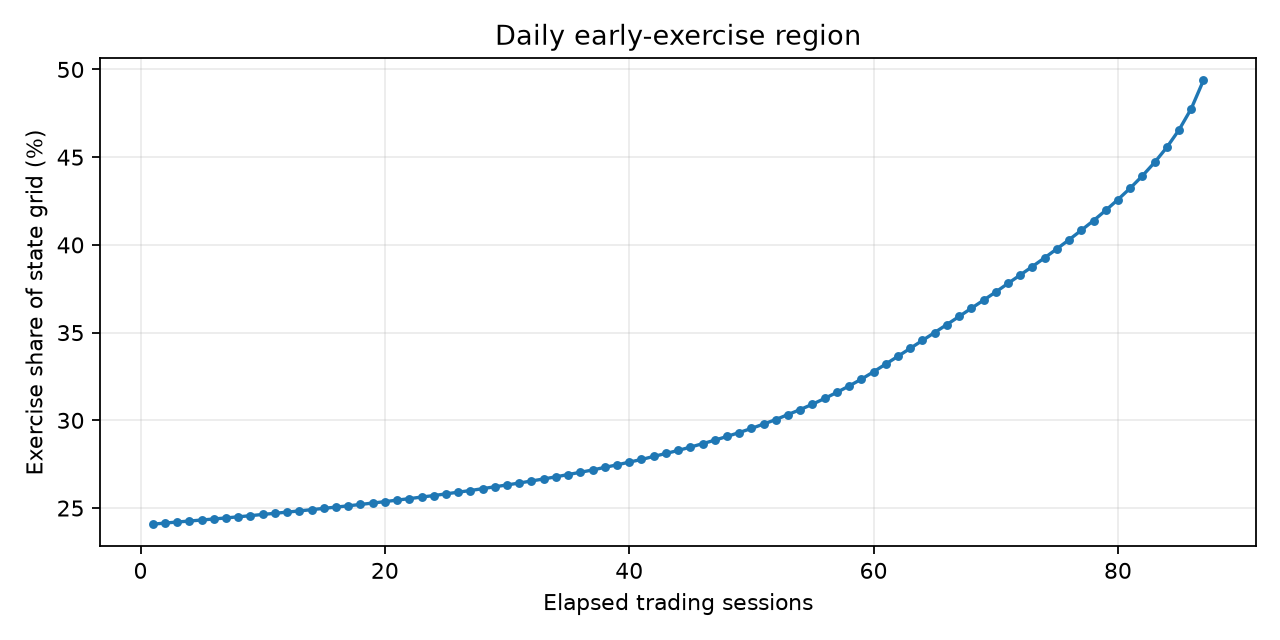

In [8]:
display(demo.pricing.grid_convergence)
display(demo.pricing.quadrature_convergence)
display(Image(filename=str(DEMO_ROOT / 'outputs' / 'charts' / 'numerical_convergence.png')))
display(Image(filename=str(DEMO_ROOT / 'outputs' / 'charts' / 'exercise_region.png')))

## 7. Interpretation limits

In [9]:
display(Markdown('\n'.join(f'- {warning}' for warning in demo.summary['warnings'])))

- Historical two-factor OU parameters are provisionally treated as risk-neutral parameters.
- Exercise is available once per trading session, so the calculation is a daily Bermudan approximation to an American option.
- The linear IM futures leg is deliberately excluded; the reported value is the carry-put optional component only.
- Spot volatility is estimated and reported but cancels from this homogeneous payoff under zero spot/carry shock correlation.
- Maturities entering 2027 use the Demo's explicit company calendar rather than the shared weekday fallback; this calendar is provisional until the official exchange schedule is available.
- The fast-minus-slow mean-reversion gap is at its upper bound of 60; the eta boundary is resolved, but fast mean reversion remains constrained.

The requested historical CSI 1000 volatility is estimated and passed into the pricing interface. Under the current zero-correlation assumptions, however, payoff homogeneity makes the option value proportional to spot and removes spot Brownian volatility from the normalized continuation problem. It will matter in an extension with spot/carry correlation or a non-homogeneous payoff.